In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np

import matplotlib.pyplot as plt

import yaml
from pathlib import Path

from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.datasets.speech_commands.config import ALL_KEYWORDS, CANONICAL, COMMAND_KEYWORDS_20, COMMAND_KEYWORDS_24
from thesis_project.utils.paths import get_data_dir

from thesis_project.models.architectures.keyword_spotting import KeyWordSpottingModel, KeyWordSpottingConfig, SpectrogramConfig, BackboneConfig, NoiseConfig, DatasetConfig



In [ ]:
%matplotlib widget

In [2]:
SKIP_TRAINING = True

KEY_WORDS_LIST = CANONICAL  # COMMAND_KEYWORDS_20  # COMMAND_KEYWORDS_24  # ALL_KEYWORDS  # CANONICAL

In [3]:
#CONFIGURATION and model initialization
spec_cfg=SpectrogramConfig(
    sample_rate=16000,
    n_fft=512,
)
backbone_cfg=BackboneConfig(
    n_channels_ext=128,
    n_channels_int=128,
    kernel_size=3,
    dropout=0.1,
    causal=True,
    n_blocks_pr_stack=3,
    dilation_base=2,
    n_stacks=3,
    residual_in_blocks=True,
    residual_in_stacks=False,
    use_custom_pw=True,
)

dataset_cfg=DatasetConfig(
    key_words=KEY_WORDS_LIST,
    use_unknown=True,
    use_silence=True,
    upsample=False,
)

noise_train_cfg=NoiseConfig(
    add_noise=True,
    noise_prob=0.8,
    snr=(-5, 15))

noise_eval_cfg=NoiseConfig(
    add_noise=True,
    noise_prob=0.8,
    snr=float("inf"))

cfg = KeyWordSpottingConfig(
    spectrogram=spec_cfg,
    backbone=backbone_cfg,
    dataset = dataset_cfg,
    noise=noise_train_cfg,
)

model = KeyWordSpottingModel(cfg)

In [4]:
# print how many model parameters we have
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized with {n_params/1e3:.1f}k trainable parameters")

Model initialized with 338.7k trainable parameters


In [5]:
# --- Load YAML file ---
#config_path = Path("/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/architectures/keyword_spotting/keyword_spotting_config.yaml")
#with open(config_path, "r") as f:
#    raw_cfg = yaml.safe_load(f)

    # --- Parse and validate with Pydantic ---
#     cfg = KeyWordSpottingConfig(
#         spectrogram=SpectrogramConfig(**raw_cfg["spectrogram"]),
#         backbone=BackboneConfig(**raw_cfg["backbone"]),
#         noise=NoiseConfig(**raw_cfg["noise"]),
#         num_classes=NUM_CLASSES,
#     )
# model = KeyWordSpottingModel(cfg)

In [6]:
data_dir = get_data_dir()

train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **noise_train_cfg.model_dump())

val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **noise_eval_cfg.model_dump())

In [7]:
# Training configuration
batch_size = 64
num_epochs = 30
init_learning_rate = 1e-3

torch.manual_seed(42)
np.random.seed(42)

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Create data loaders (no num_workers for MPS compatibility)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=init_learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",      # we want to minimize val loss
    factor=0.5,      # reduce LR by a factor of 0.5
    patience=3,      # epochs with no improvement before reducing LR
)

Using MPS


In [8]:
# print number of trinable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {n_params/1e3:.1f}k trainable parameters")

Model has 338.7k trainable parameters


In [9]:
def validate_model(model, val_loader, criterion, device, snr_values=None, verbose=True):
    """
    Evaluate `model` on the same validation set for different SNR values.

    Assumes:
        - val_loader.dataset._set_snr(snr) exists.
        - val_loader yields (waveform, label, meta).
    """
    if snr_values is None:
        snr_values = [None]

    model.eval()
    results = {}

    ds = val_loader.dataset  # the dataset bound to this loader

    with torch.no_grad():
        for snr in snr_values:
            # ---- SET THE SNR FOR THIS PASS ----
            ds._set_snr(snr)

            total_loss = 0.0
            total_correct = 0
            total_samples = 0

            pbar = tqdm(val_loader, desc=f"SNR={snr}", leave=False)
            for waveforms, labels, meta in pbar:
                waveforms = waveforms.to(device)
                labels = labels.to(device)

                logits = model(waveforms)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                total_samples += batch_size
                total_loss += loss.item() * batch_size

                preds = logits.argmax(dim=1)
                total_correct += (preds == labels).sum().item()

                # live progress
                pbar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    acc=f"{100 * total_correct / total_samples:.2f}%",
                )

            avg_loss = total_loss / total_samples
            avg_acc = 100.0 * total_correct / total_samples

            results[snr] = {"loss": avg_loss, "acc": avg_acc}

            if verbose:
                print(f"SNR={snr}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%")

    return results

In [10]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

# Which SNRs you want to evaluate at each epoch
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]  # inf means no noise added
MAIN_VAL_SNR = float('inf')  # which SNR to use as "main" val metric (for curves)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],   # for MAIN_VAL_SNR
    "val_acc": [],    # for MAIN_VAL_SNR
    "val_per_snr": [] # list of dicts: {snr: {"loss": ..., "acc": ...}, ...}
}

best_val_acc = -float("inf")
best_model_path = "keyword_spotting_best_val_acc.pth"

if not SKIP_TRAINING:
    for epoch in range(num_epochs):
        # ----------------------- TRAINING -----------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for waveforms, labels, _ in train_pbar:  # Dataset returns (waveform, label, metadata)
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(waveforms)
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            # Stats
            batch_size = waveforms.size(0)
            train_total += batch_size
            train_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / train_total:.2f}%'
            })
        
        # Use train_total to be robust to drop_last, etc.
        train_loss_epoch = train_loss / train_total
        train_acc_epoch = 100.0 * train_correct / train_total

        # ----------------------- VALIDATION -----------------------
        val_results = validate_model(
            model,
            val_loader,
            criterion,
            device,
            snr_values=VAL_SNR_VALUES,
            verbose=False,
        )

        # Pick the "main" validation metric
        main_val = val_results[MAIN_VAL_SNR]
        val_loss_epoch = main_val["loss"]
        val_acc_epoch = main_val["acc"]

        # ----------------------- LR SCHEDULER STEP -----------------------
        # ReduceLROnPlateau expects a scalar; we use val_loss as signal
        scheduler.step(val_loss_epoch)

        # ----------------------- LOGGING / HISTORY -----------------------
        history["train_loss"].append(train_loss_epoch)
        history["train_acc"].append(train_acc_epoch)
        history["val_loss"].append(val_loss_epoch)
        history["val_acc"].append(val_acc_epoch)
        history["val_per_snr"].append(val_results)

        # Log current LR
        current_lr = optimizer.param_groups[0]["lr"]
        history.setdefault("lr", []).append(current_lr)
        print(f"  LR: {current_lr:.6f}")

        # ----------------------- BEST MODEL CHECKPOINT -------------------
        if val_acc_epoch > best_val_acc:
            best_val_acc = val_acc_epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"\n>>> New best model! Val Acc = {best_val_acc:.2f}%. Saved to {best_model_path}")

        # Epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"  Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.2f}%")
        print(f"  Val Loss (SNR={MAIN_VAL_SNR}): {val_loss_epoch:.4f}, Val Acc: {val_acc_epoch:.2f}%")

        print("\n=== Val Accuracy per SNR ===")
        for snr, stats in val_results.items():
            print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
        print("-" * 60)

    print("Training completed!")
    print(f"Best val accuracy: {best_val_acc:.2f}%. Best model saved to {best_model_path}")

    # save the training history to file
    history_path = "keyword_spotting_training_history.npy"
    np.save(history_path, history)

else:
    trained_model_path = "3_stacks_keyword_spotting_best_val_acc.pth"
    trained_model_history_path = "3_stacks_keyword_spotting_training_history.npy"
    model.load_state_dict(torch.load(trained_model_path, map_location=device))
    history = np.load(trained_model_history_path, allow_pickle=True).item()

In [11]:
import matplotlib.pyplot as plt
import math

def plot_history_with_snr_avg(
    history: dict,
    main_val_snr: float = float('inf'),
    snrs_for_avg: list[float] | None = None,
):
    """
    Plot train/val loss and accuracy, plus the average val metrics across SNRs.

    Args:
        history: dict filled during training (as in your code).
        main_val_snr: SNR that was used for history["val_loss"] / ["val_acc"].
        snrs_for_avg: Which SNRs to include in the average. 
                      If None, uses all SNRs found in val_per_snr for each epoch.
    """
    train_loss = history["train_loss"]
    train_acc  = history["train_acc"]
    val_loss   = history["val_loss"]   # main SNR
    val_acc    = history["val_acc"]    # main SNR
    val_per_snr = history["val_per_snr"]

    num_epochs = len(train_loss)
    epochs = range(1, num_epochs + 1)

    # --- Compute average val metrics across SNRs for each epoch ---
    val_loss_avg = []
    val_acc_avg = []

    for epoch_dict in val_per_snr:  # one dict per epoch: {snr: {"loss": ..., "acc": ...}}
        # Decide which SNRs to include in the average for this epoch
        if snrs_for_avg is None:
            snrs = list(epoch_dict.keys())
        else:
            snrs = [s for s in snrs_for_avg if s in epoch_dict]

        losses = [epoch_dict[snr]["loss"] for snr in snrs]
        accs   = [epoch_dict[snr]["acc"]  for snr in snrs]

        val_loss_avg.append(sum(losses) / len(losses))
        val_acc_avg.append(sum(accs) / len(accs))

    # --- Plot: Loss ---
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss,   label=f"Val Loss (SNR={main_val_snr})")
    plt.plot(epochs, val_loss_avg, label="Val Loss (avg over SNR)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Plot: Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, val_acc,   label=f"Val Acc (SNR={main_val_snr})")
    plt.plot(epochs, val_acc_avg, label="Val Acc (avg over SNR)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy vs Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


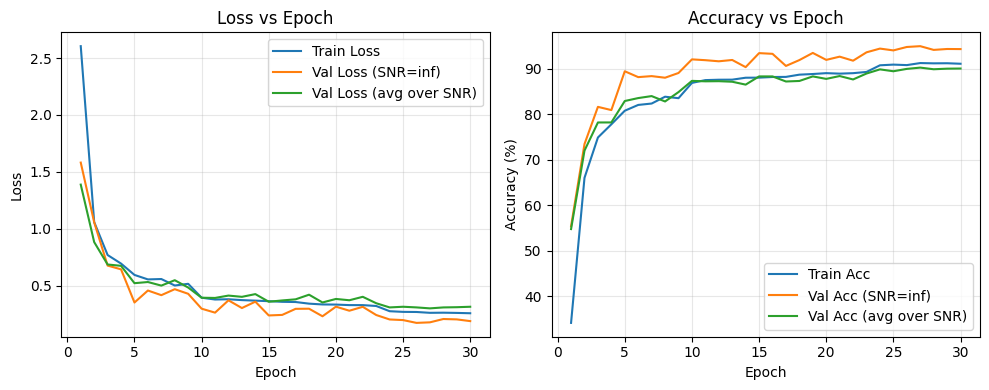

In [12]:
plot_history_with_snr_avg(history, main_val_snr=MAIN_VAL_SNR,
                          snrs_for_avg=VAL_SNR_VALUES)

In [13]:
# do a validation pass to see final performance
final_val_results = validate_model(
    model,
    val_loader,
    criterion,
    device,
    snr_values=VAL_SNR_VALUES,
    verbose=False,
)
print("Final evaluation on validation set completed.")
print("\n=== Val Accuracy per SNR ===")
for snr, stats in final_val_results.items():
    print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
print("-" * 60)

Final evaluation on validation set completed.

=== Val Accuracy per SNR ===
  SNR=    -5: acc=79.71%  loss=0.5884
  SNR=     0: acc=87.84%  loss=0.3601
  SNR=     5: acc=91.74%  loss=0.2672
  SNR=    10: acc=93.20%  loss=0.2207
  SNR=    15: acc=94.11%  loss=0.1956
  SNR=   inf: acc=94.97%  loss=0.1792
------------------------------------------------------------


In [14]:
def evaluate_rank_sweep(
    model,
    compressible_layers,
    validate_fn,
    val_loader,
    criterion,
    device,
    max_rank,
    snr_values,
    step=4,
    compress_frontend=False,
    verbose=True,
):
    """
    Sweep across target ranks for CPC_Conv1d layers and record validation accuracy.

    Args:
        model (nn.Module): Your model containing CPC_Conv1d layers.
        compressible_layers (list[tuple[str, nn.Module]]): (name, layer) pairs of CPC_Conv1d layers.
        validate_fn (callable): Validation function (model, val_loader, criterion, device, snr_values, verbose) -> dict
        val_loader (DataLoader): Validation dataloader.
        criterion (nn.Module): Loss function.
        device (torch.device): Torch device.
        max_rank (int): Maximum rank (usually = in_channels = out_channels).
        snr_values (list): List of SNR values to evaluate.
        step (int, optional): Step size for the rank sweep. Default = 4.
        compress_frontend (bool, optional): If False, skip compressing the "frontend" layer.
        verbose (bool, optional): Print progress messages.

    Returns:
        list[tuple[int, dict]]: List of (target_rank, per_noise_results) results.
    """
    val_acc_results = []

    for target_rank in range(step, max_rank + 1, step):
        # --- Activate low-rank ---
        for name, layer in compressible_layers:
            if (not compress_frontend) and (name == "frontend"):
                continue
            layer.activate_low_rank(rank=target_rank)

        # --- Validate ---
        # validate_fn is expected to be validate_model which returns a dict {snr: {acc, loss}}
        per_noise = validate_fn(model, val_loader, criterion, device, snr_values=snr_values, verbose=False)
        val_acc_results.append((target_rank, per_noise))

        if verbose:
            # Compute average accuracy for printing
            avg_acc = sum(d['acc'] for d in per_noise.values()) / len(per_noise) if per_noise else 0.0
            print(f"[Rank {target_rank:>3}] Val Acc (Avg): {avg_acc:.3f}%")
            for np_val, v in per_noise.items():
                print(f"  noise={str(np_val):>6}: acc={v['acc']:.2f}%  loss={v['loss']:.4f}")

    return val_acc_results

In [15]:
def plot_rank_vs_accuracy_by_noise(
    results,                 # list of (rank: int, per_noise: dict[noise_param -> {'acc': float, 'loss': float}])
    title=None,
    save_path=None,
    metric="acc",            # "acc" or "loss"
    show_flops=True,         # keep the secondary y-axis like before
):
    """
    Plot {metric} vs. rank with one curve per noise_param.

    Example input:
    results = [
        (4, {0.0:{'acc':14.76,'loss':4.07}, 0.05:{'acc':21.62,'loss':4.06}}),
        (8, {0.0:{'acc':20.65,'loss':4.06}, 0.05:{'acc':34.11,'loss':4.05}})
    ]
    """

    # --- collect and sort ranks ---
    ranks = sorted(int(r) for r, _ in results)
    rank_to_dict = {int(r): d for r, d in results}

    # --- gather all noise params across ranks ---
    all_noise = set()
    for d in rank_to_dict.values():
        for k in d.keys():
            try:
                all_noise.add(float(k))
            except Exception:
                # ignore non-numeric noise keys
                pass
    noise_params = sorted(all_noise)  # numeric sort

    # --- build series per noise param aligned to 'ranks' order ---
    series = {}  # noise_param -> list of metric values aligned with ranks
    for np_val in noise_params:
        vals = []
        for r in ranks:
            entry = rank_to_dict[r].get(np_val, None)
            if entry is None or metric not in entry:
                vals.append(np.nan)  # missing value creates a gap in the curve
            else:
                vals.append(entry[metric])
        series[np_val] = vals

    # --- relative FLOPs for PW conv (same as your original logic) ---
    C = max(ranks) if ranks else 1
    flops_rel = [2 * r / C for r in ranks]  # =1 when r=C/2

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # left axis: metric per noise
    for np_val, vals in series.items():
        ax1.plot(ranks, vals, marker='o', label=f"noise std={np_val:g}")

    ax1.set_xlabel("Target Rank")
    ylab = "Validation Accuracy (%)" if metric == "acc" else "Validation Loss"
    ax1.set_ylabel(ylab)
    ax1.grid(True, alpha=0.4)

    # helpful vertical reference at C//2
    ax1.axvline(x=C // 2, color='r', linestyle='--', linewidth=1, label='Max Rank // 2')

    # right axis: relative FLOPs (optional)
    if show_flops:
        ax2 = ax1.twinx()
        ax2.plot(ranks, flops_rel, linestyle='-', alpha=0.6, label="Relative PW FLOPs")
        ax2.set_ylabel("Relative PW FLOPs (vs full conv)")
        # Handle legends from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    else:
        ax1.legend(loc="best")

    # title
    if title is None:
        base = "Validation Accuracy vs. Target Rank" if metric == "acc" \
               else "Validation Loss vs. Target Rank"
        if show_flops:
            base += " (with Relative PW FLOPs)"
        title = base
    plt.title(title)

    # save or show
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Plot saved to {save_path}")
        plt.close(fig)
    else:
        plt.tight_layout()
        plt.show()


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_rank_vs_snr_vs_accuracy_3d(results, title="Rank vs SNR vs Accuracy"):
    """
    Create a 3D plot of Rank vs SNR vs Accuracy.
    
    Args:
        results: list of (rank, per_noise_dict) tuples.
                 per_noise_dict keys are SNR values (can be float or 'inf').
                 per_noise_dict values are {'acc': float, 'loss': float}.
    """
    # Check backend to ensure interactivity
    backend = plt.get_backend()
    if 'ipympl' not in backend and 'widget' not in backend:
        print(f"Warning: Current matplotlib backend is '{backend}'. For interactive 3D plots, ensure %matplotlib widget is run and ipympl is installed.")

    ranks = []
    snrs = []
    accs = []

    for rank, per_noise in results:
        for snr, stats in per_noise.items():
            # Handle potential string 'inf' or float('inf')
            try:
                snr_val = float(snr)
            except ValueError:
                continue # Skip if not convertible to float
                
            # Ignore inf for now as requested
            if snr_val == float('inf'):
                continue
            
            ranks.append(rank)
            snrs.append(snr_val)
            accs.append(stats['acc'])

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    unique_ranks = sorted(list(set(ranks)))
    unique_snrs = sorted(list(set(snrs)))
    
    # Check if we have a complete grid to use plot_surface
    if len(ranks) > 0 and len(ranks) == len(unique_ranks) * len(unique_snrs):
        # It's a grid
        X, Y = np.meshgrid(unique_ranks, unique_snrs)
        Z = np.zeros_like(X, dtype=float)
        
        # Create a lookup for (rank, snr) -> acc
        lookup = {}
        for r, s, a in zip(ranks, snrs, accs):
            lookup[(r, s)] = a
            
        for i in range(len(unique_snrs)):
            for j in range(len(unique_ranks)):
                r = unique_ranks[j]
                s = unique_snrs[i]
                Z[i, j] = lookup.get((r, s), np.nan)
                
        surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Accuracy (%)')
    else:
        # Fallback to scatter if not a perfect grid or empty
        img = ax.scatter(ranks, snrs, accs, c=accs, cmap='viridis', marker='o')
        fig.colorbar(img, ax=ax, shrink=0.5, aspect=5, label='Accuracy (%)')

    ax.set_xlabel('Model Rank')
    ax.set_ylabel('SNR Noise Level (dB)')
    ax.set_zlabel('Validation Accuracy (%)')
    ax.set_title(title)

    plt.show()

In [17]:
from thesis_project.models.blocks import CPC_Conv1d
compressible_layers = []
for name, layer in model.named_modules():
    if isinstance(layer, CPC_Conv1d):
        W = layer.weight_full.squeeze(-1)
        max_rank = min(W.shape)
        print(f"{name}: max_rank = {max_rank}")
        compressible_layers.append((name, layer))

backbone.0.0.cpw_conv1: max_rank = 128
backbone.0.0.cpw_conv2: max_rank = 128
backbone.0.1.cpw_conv1: max_rank = 128
backbone.0.1.cpw_conv2: max_rank = 128
backbone.0.2.cpw_conv1: max_rank = 128
backbone.0.2.cpw_conv2: max_rank = 128
backbone.1.0.cpw_conv1: max_rank = 128
backbone.1.0.cpw_conv2: max_rank = 128
backbone.1.1.cpw_conv1: max_rank = 128
backbone.1.1.cpw_conv2: max_rank = 128
backbone.1.2.cpw_conv1: max_rank = 128
backbone.1.2.cpw_conv2: max_rank = 128
backbone.2.0.cpw_conv1: max_rank = 128
backbone.2.0.cpw_conv2: max_rank = 128
backbone.2.1.cpw_conv1: max_rank = 128
backbone.2.1.cpw_conv2: max_rank = 128
backbone.2.2.cpw_conv1: max_rank = 128
backbone.2.2.cpw_conv2: max_rank = 128
frontend: max_rank = 128


In [18]:
results = {}

results["val_acc_results"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128, #128
    snr_values=VAL_SNR_VALUES,
    step=4,
    compress_frontend=False,
    verbose=True
)

/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/blocks/cpc.py:31: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, S, Vt = torch.linalg.svd(W, full_matrices=False)


[Rank   4] Val Acc (Avg): 16.774%
  noise=    -5: acc=12.18%  loss=3.2867
  noise=     0: acc=15.24%  loss=3.1181
  noise=     5: acc=18.18%  loss=2.9977
  noise=    10: acc=18.52%  loss=2.9190
  noise=    15: acc=18.25%  loss=2.8706
  noise=   inf: acc=18.27%  loss=3.2705


[Rank   8] Val Acc (Avg): 52.215%
  noise=    -5: acc=40.04%  loss=1.8157
  noise=     0: acc=48.33%  loss=1.5476
  noise=     5: acc=54.22%  loss=1.3889
  noise=    10: acc=57.76%  loss=1.3045
  noise=    15: acc=59.29%  loss=1.2663
  noise=   inf: acc=53.64%  loss=1.5165


[Rank  12] Val Acc (Avg): 77.685%
  noise=    -5: acc=61.90%  loss=1.2284
  noise=     0: acc=72.91%  loss=0.8421
  noise=     5: acc=79.22%  loss=0.6414
  noise=    10: acc=83.17%  loss=0.5238
  noise=    15: acc=85.36%  loss=0.4577
  noise=   inf: acc=83.54%  loss=0.5455


[Rank  16] Val Acc (Avg): 85.722%
  noise=    -5: acc=72.93%  loss=0.8391
  noise=     0: acc=81.86%  loss=0.5422
  noise=     5: acc=86.89%  loss=0.3957
  noise=    10: acc=89.55%  loss=0.3197
  noise=    15: acc=91.03%  loss=0.2767
  noise=   inf: acc=92.07%  loss=0.2628


...

[Rank 112] Val Acc (Avg): 90.281%
  noise=    -5: acc=79.80%  loss=0.5885
  noise=     0: acc=87.77%  loss=0.3599
  noise=     5: acc=91.81%  loss=0.2669
  noise=    10: acc=93.18%  loss=0.2203
  noise=    15: acc=94.11%  loss=0.1950
  noise=   inf: acc=95.02%  loss=0.1790


[Rank 116] Val Acc (Avg): 90.251%
  noise=    -5: acc=79.69%  loss=0.5885
  noise=     0: acc=87.80%  loss=0.3601
  noise=     5: acc=91.74%  loss=0.2671
  noise=    10: acc=93.20%  loss=0.2205
  noise=    15: acc=94.11%  loss=0.1953
  noise=   inf: acc=94.97%  loss=0.1789


[Rank 120] Val Acc (Avg): 90.262%
  noise=    -5: acc=79.73%  loss=0.5884
  noise=     0: acc=87.82%  loss=0.3600
  noise=     5: acc=91.74%  loss=0.2672
  noise=    10: acc=93.20%  loss=0.2207
  noise=    15: acc=94.11%  loss=0.1955
  noise=   inf: acc=94.97%  loss=0.1791


[Rank 124] Val Acc (Avg): 90.262%
  noise=    -5: acc=79.69%  loss=0.5884
  noise=     0: acc=87.84%  loss=0.3601
  noise=     5: acc=91.74%  loss=0.2671
  noise=    10: acc=93.22%  loss=0.2207
  noise=    15: acc=94.11%  loss=0.1955
  noise=   inf: acc=94.97%  loss=0.1792


[Rank 128] Val Acc (Avg): 90.262%
  noise=    -5: acc=79.71%  loss=0.5884
  noise=     0: acc=87.84%  loss=0.3601
  noise=     5: acc=91.74%  loss=0.2672
  noise=    10: acc=93.20%  loss=0.2207
  noise=    15: acc=94.11%  loss=0.1956
  noise=   inf: acc=94.97%  loss=0.1792


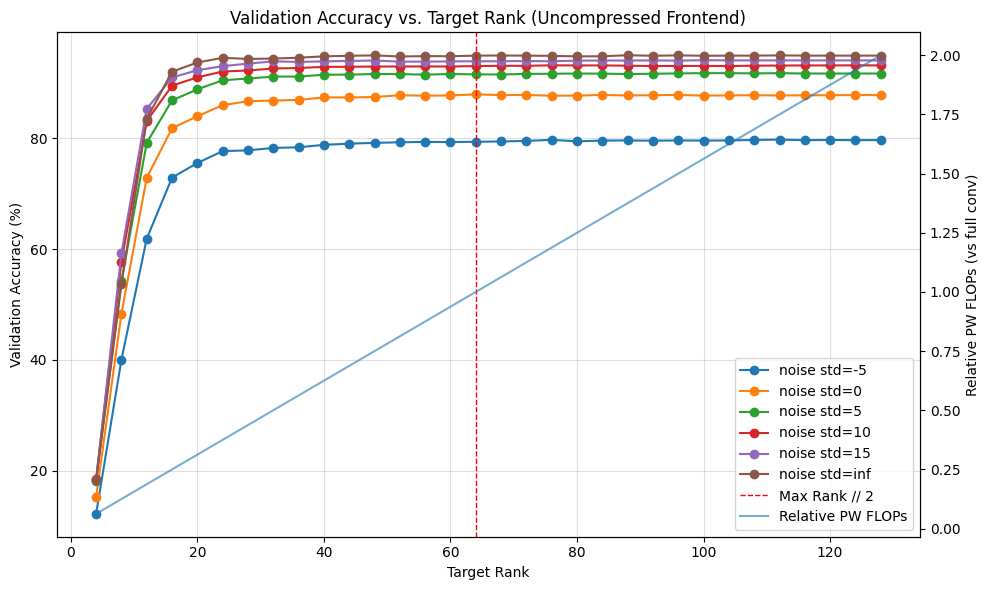

In [28]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results"],
    title="Validation Accuracy vs. Target Rank (Uncompressed Frontend)",
    metric="acc",
    show_flops=True
)

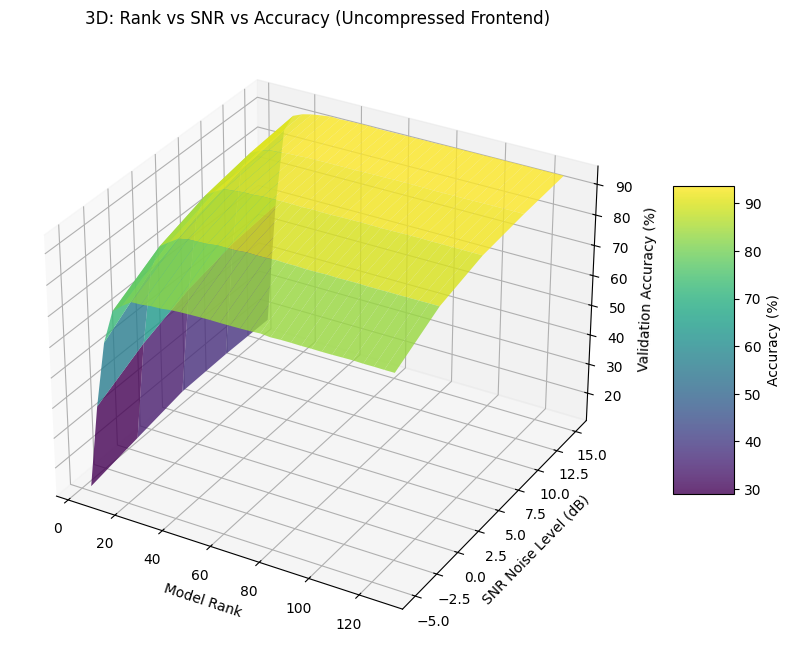

In [29]:
plot_rank_vs_snr_vs_accuracy_3d(
    results=results["val_acc_results"],
    title="3D: Rank vs SNR vs Accuracy (Uncompressed Frontend)"
)

### COMPRESSED FRONTEND RESULTS

In [21]:
results["val_acc_results_compressed_frontend"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128, #128
    snr_values=VAL_SNR_VALUES,
    step=4,
    compress_frontend=True,
    verbose=True
)

[Rank   4] Val Acc (Avg): 12.326%
  noise=    -5: acc=10.81%  loss=3.0389
  noise=     0: acc=11.21%  loss=3.0085
  noise=     5: acc=11.85%  loss=2.9777
  noise=    10: acc=12.65%  loss=2.9527
  noise=    15: acc=13.47%  loss=2.9357
  noise=   inf: acc=13.98%  loss=3.0100


[Rank   8] Val Acc (Avg): 29.428%
  noise=    -5: acc=16.94%  loss=2.6884
  noise=     0: acc=23.39%  loss=2.3092
  noise=     5: acc=30.65%  loss=2.0122
  noise=    10: acc=35.35%  loss=1.8354
  noise=    15: acc=38.25%  loss=1.7608
  noise=   inf: acc=31.98%  loss=2.2613


[Rank  12] Val Acc (Avg): 58.808%
  noise=    -5: acc=37.74%  loss=2.7079
  noise=     0: acc=57.03%  loss=1.5783
  noise=     5: acc=66.05%  loss=1.1677
  noise=    10: acc=68.55%  loss=1.0539
  noise=    15: acc=68.77%  loss=1.0534
  noise=   inf: acc=54.71%  loss=1.8531


[Rank  16] Val Acc (Avg): 71.580%
  noise=    -5: acc=59.73%  loss=1.3875
  noise=     0: acc=71.03%  loss=0.9578
  noise=     5: acc=76.92%  loss=0.7716
  noise=    10: acc=78.80%  loss=0.7142
  noise=    15: acc=79.11%  loss=0.7346
  noise=   inf: acc=63.88%  loss=1.7965


[Rank  20] Val Acc (Avg): 74.086%
  noise=    -5: acc=62.19%  loss=1.2173
  noise=     0: acc=72.89%  loss=0.8386
  noise=     5: acc=79.38%  loss=0.6692
  noise=    10: acc=81.66%  loss=0.6101
  noise=    15: acc=82.15%  loss=0.6156
  noise=   inf: acc=66.25%  loss=1.6171


...

[Rank 112] Val Acc (Avg): 88.512%
  noise=    -5: acc=78.69%  loss=0.6121
  noise=     0: acc=87.20%  loss=0.3849
  noise=     5: acc=90.56%  loss=0.2955
  noise=    10: acc=91.78%  loss=0.2562
  noise=    15: acc=92.62%  loss=0.2428
  noise=   inf: acc=90.21%  loss=0.3728


[Rank 116] Val Acc (Avg): 89.420%
  noise=    -5: acc=79.31%  loss=0.5982
  noise=     0: acc=87.60%  loss=0.3690
  noise=     5: acc=91.32%  loss=0.2767
  noise=    10: acc=92.65%  loss=0.2337
  noise=    15: acc=93.53%  loss=0.2138
  noise=   inf: acc=92.12%  loss=0.2906


[Rank 120] Val Acc (Avg): 89.723%
  noise=    -5: acc=79.53%  loss=0.5947
  noise=     0: acc=87.69%  loss=0.3654
  noise=     5: acc=91.47%  loss=0.2742
  noise=    10: acc=92.69%  loss=0.2323
  noise=    15: acc=93.67%  loss=0.2127
  noise=   inf: acc=93.29%  loss=0.2619


[Rank 124] Val Acc (Avg): 90.244%
  noise=    -5: acc=79.65%  loss=0.5893
  noise=     0: acc=87.93%  loss=0.3594
  noise=     5: acc=91.83%  loss=0.2664
  noise=    10: acc=93.22%  loss=0.2205
  noise=    15: acc=94.13%  loss=0.1966
  noise=   inf: acc=94.71%  loss=0.1935


[Rank 128] Val Acc (Avg): 90.262%
  noise=    -5: acc=79.71%  loss=0.5884
  noise=     0: acc=87.84%  loss=0.3601
  noise=     5: acc=91.74%  loss=0.2672
  noise=    10: acc=93.20%  loss=0.2207
  noise=    15: acc=94.11%  loss=0.1956
  noise=   inf: acc=94.97%  loss=0.1792


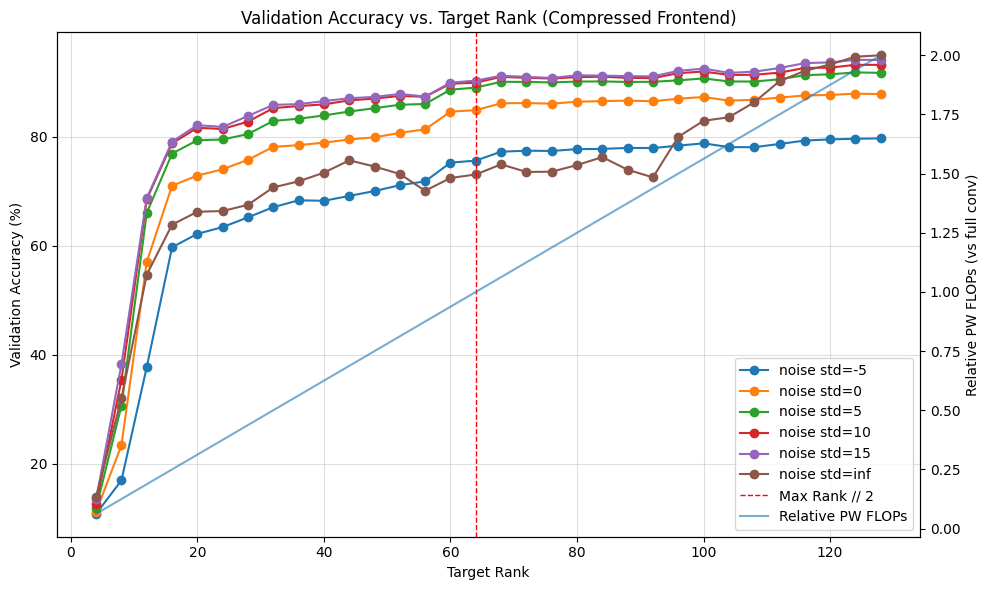

In [22]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results_compressed_frontend"],
    title="Validation Accuracy vs. Target Rank (Compressed Frontend)",
    metric="acc",
    show_flops=True
)

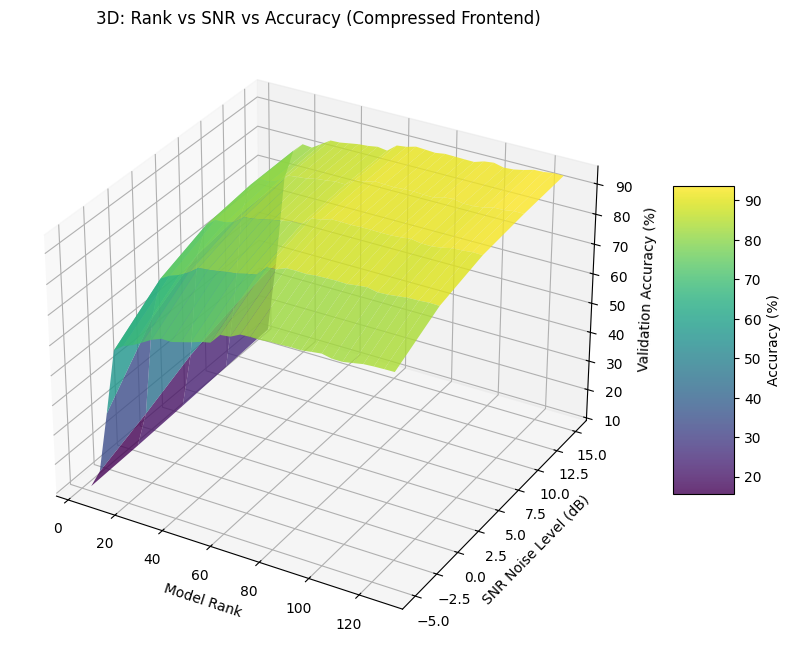

In [23]:
plot_rank_vs_snr_vs_accuracy_3d(
    results=results["val_acc_results_compressed_frontend"],
    title="3D: Rank vs SNR vs Accuracy (Compressed Frontend)"
)